# 02 — Feature engineering
Builds one row per PPG from the weekly panel. Logic lives in `src/features.py`

In [17]:
import sys
sys.path.insert(0, "../src")
import pandas as pd
from features import build_ppg_features
from anomaly_checking import flag_anomalies

raw = pd.read_csv("../data/raw/ECON_POS_anonymized.csv", low_memory=False)
feats = build_ppg_features(raw)

anoms = flag_anomalies(feats)
feats = feats[~anoms.is_anomaly]

feats.shape

/var/folders/x5/r4w2c_cd40zdm0v1m88mm_yw0000gn/T/ipykernel_13005/1411951098.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  feats = feats[~anoms.is_anomaly]


(347, 49)

In [18]:
feats.isna().any().any(), feats.describe().T

(np.False_,
                                 count          mean           std        min  \
 n_weeks                         347.0    117.806916     43.652730   3.000000   
 avg_weekly_sales                347.0  17780.176894  29597.835123  43.754449   
 avg_weekly_units                347.0   4874.320670   7952.966088  69.027523   
 avg_acv                         347.0     18.273767     22.247612   0.016218   
 sales_cv                        347.0      1.263743      0.988041   0.109784   
 is_new                          347.0      0.074928      0.263655   0.000000   
 is_delisted                     347.0      0.146974      0.354591   0.000000   
 recent_avg_sales                347.0  14718.213242  32224.078749   0.082500   
 growth_rate                     347.0     -0.027455      0.108964  -0.949969   
 acv_trend                       347.0     -0.120318      0.350200  -3.969848   
 momentum                        347.0      5.127964     77.326319   0.002254   
 mat_growth     

## Distributions and correlation
Checking these before picking clustering features

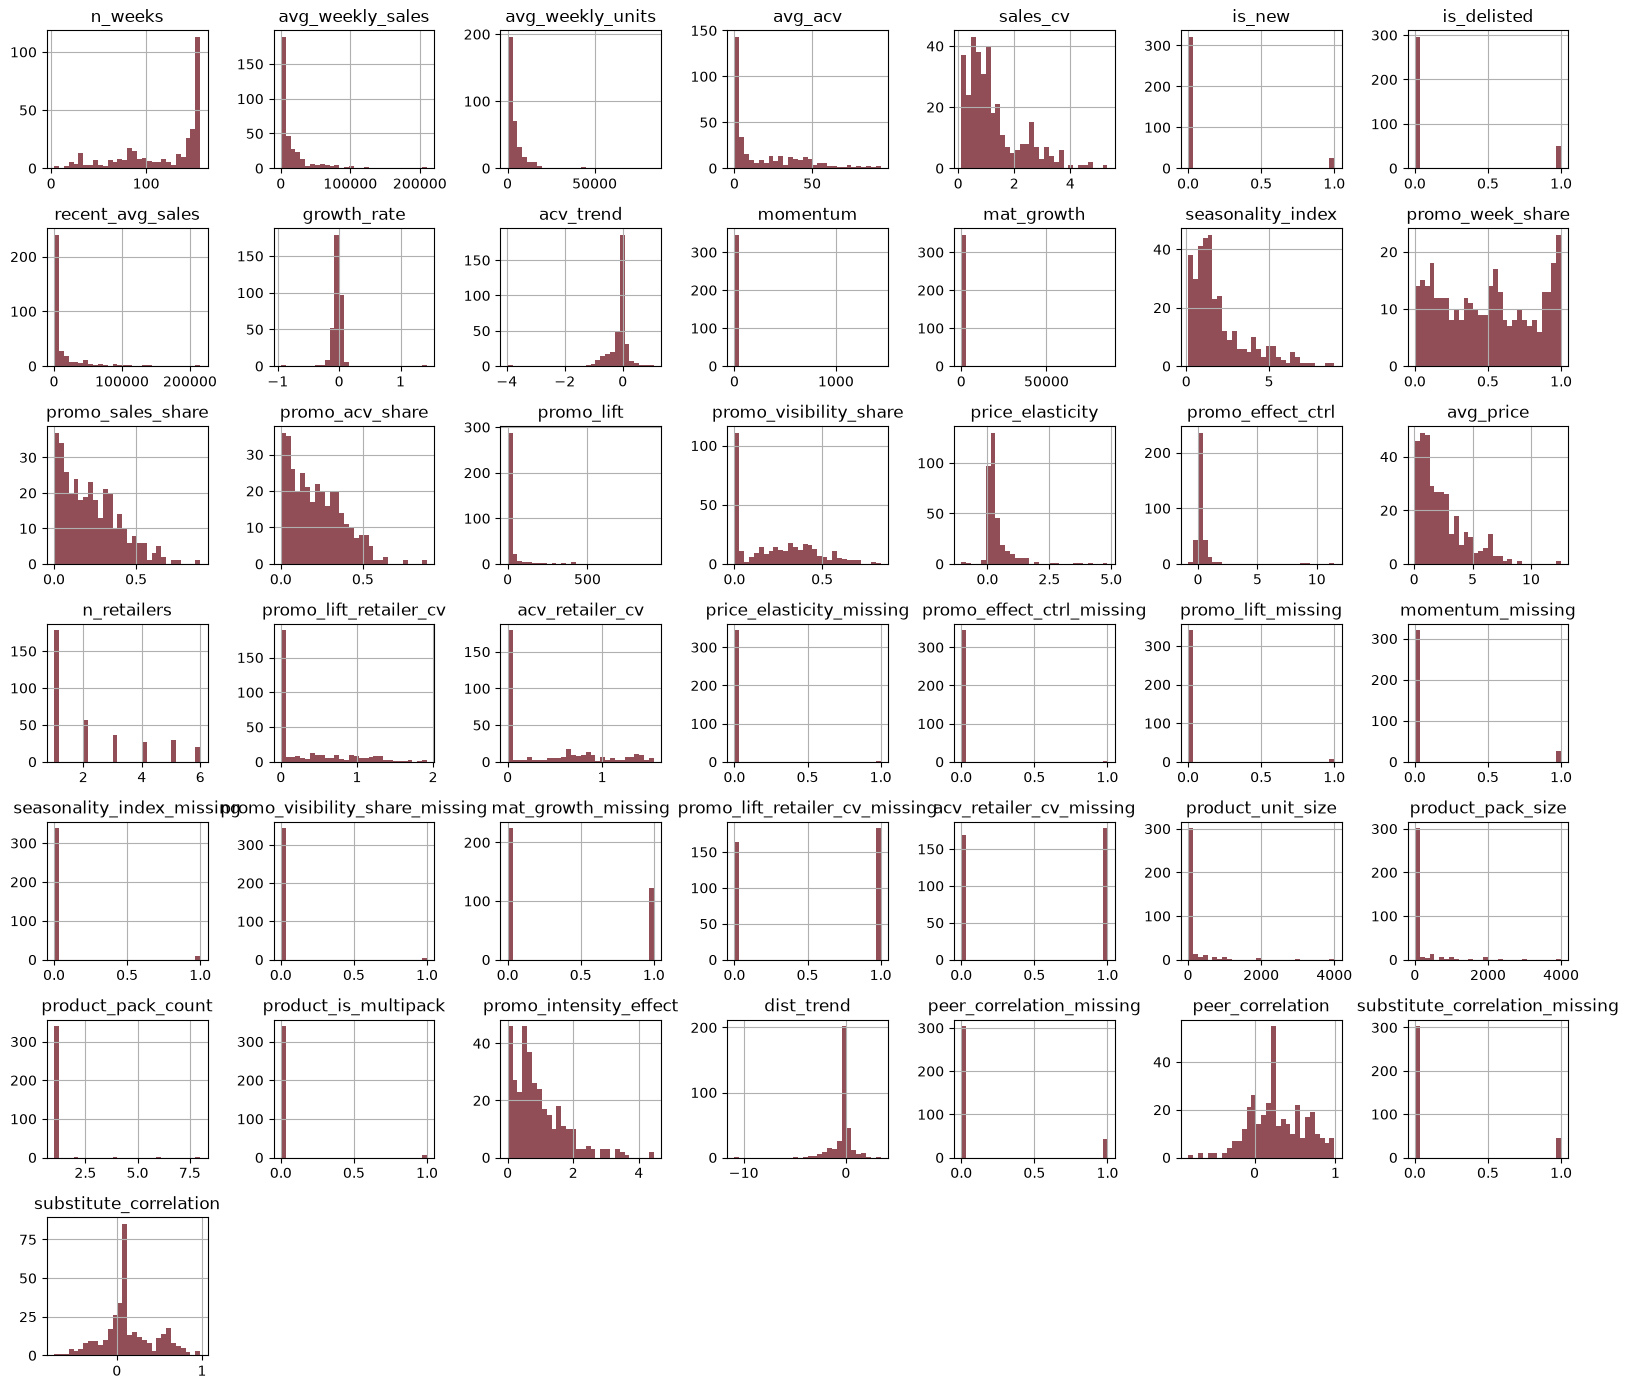

In [19]:
import matplotlib.pyplot as plt

FEATURE_COLS_CANDIDATE = [
    "n_weeks", "avg_weekly_sales", "avg_weekly_units", "avg_acv", "sales_cv",
    "is_new", "is_delisted", "growth_rate", "momentum", "mat_growth",
    "seasonality_index", "promo_week_share", "promo_sales_share",
    "promo_acv_share", "promo_lift", "price_elasticity", "promo_effect_ctrl",
    "avg_price", "n_retailers",
]
FEATURE_COLS_CANDIDATE = feats.select_dtypes(include="number").columns.tolist()
feats[FEATURE_COLS_CANDIDATE].hist(bins=30, figsize=(16, 14), color="#914E56")
plt.tight_layout()
plt.show()

In [20]:
feats[FEATURE_COLS_CANDIDATE].skew().sort_values(ascending=False)

mat_growth                        18.627917
momentum                          18.623727
promo_effect_ctrl_missing         10.661007
price_elasticity_missing          10.661007
promo_visibility_share_missing     9.191922
promo_effect_ctrl                  9.070643
product_pack_count                 8.838011
promo_lift_missing                 6.855505
product_is_multipack               6.855505
product_unit_size                  6.349140
seasonality_index_missing          5.991009
avg_weekly_units                   5.191815
product_pack_size                  5.138080
growth_rate                        5.058999
promo_lift                         4.993273
price_elasticity                   3.807250
recent_avg_sales                   3.308227
is_new                             3.243146
momentum_missing                   3.165880
avg_weekly_sales                   3.161130
peer_correlation_missing           2.292731
substitute_correlation_missing     2.252868
is_delisted                     

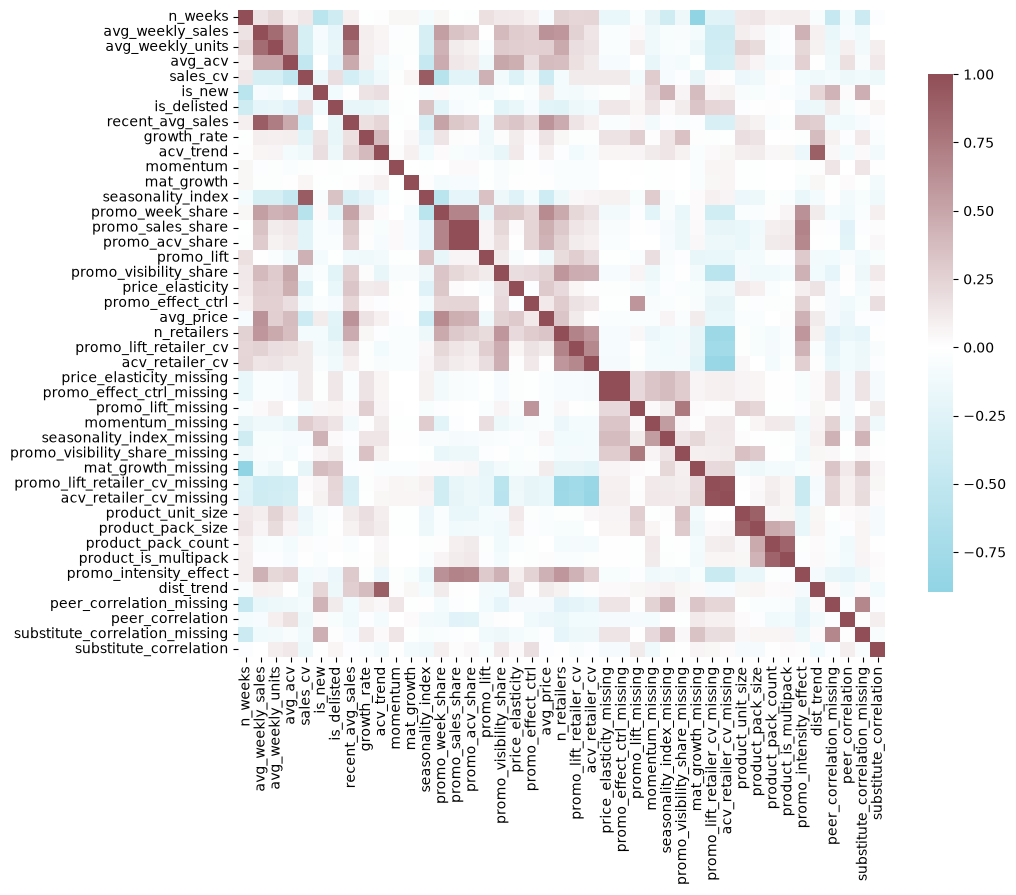

In [21]:
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

wera = LinearSegmentedColormap.from_list(
    "wera",
    ["#85CFE1", "#FFFFFF", "#914E56"]
)

corr = feats[FEATURE_COLS_CANDIDATE].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap=wera, center=0, square=True, cbar_kws={"shrink": 0.8})
plt.tight_layout()
plt.show()

In [22]:
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(16)

price_elasticity_missing        promo_effect_ctrl_missing         1.000000
promo_sales_share               promo_acv_share                   0.988986
promo_lift_retailer_cv_missing  acv_retailer_cv_missing           0.971545
sales_cv                        seasonality_index                 0.917538
avg_weekly_sales                recent_avg_sales                  0.905629
acv_trend                       dist_trend                        0.903068
n_weeks                         mat_growth_missing               -0.897016
product_unit_size               product_pack_size                 0.894002
product_pack_count              product_is_multipack              0.867083
acv_retailer_cv                 acv_retailer_cv_missing          -0.850623
avg_weekly_sales                avg_weekly_units                  0.822348
acv_retailer_cv                 promo_lift_retailer_cv_missing   -0.816495
n_retailers                     promo_lift_retailer_cv_missing   -0.795623
                         

`promo_sales_share`/`promo_acv_share` (0.99), `sales_cv`/`seasonality_index` (0.92), `avg_weekly_sales`/`recent_avg_sales` (0.91), and `acv_trend`/`dist_trend` (0.91) are highly correlated, so keeping one feature from each pair should be enough. `momentum`, `mat_growth`, `promo_lift`, and a few other continuous features are heavily skewed (see above), so they should be log-transformed before scaling.

In [23]:
import os
os.makedirs("../data/processed", exist_ok=True)
feats.to_csv("../data/processed/ppg_features.csv")